### Data Load 

In [170]:
from linearmodels.panel import PanelOLS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [98]:
assessments = pd.read_csv("data/assessments.csv")
courses = pd.read_csv("data/courses.csv")
studentAssessment = pd.read_csv("data/studentAssessment.csv")
studentInfo = pd.read_csv("data/studentInfo.csv")
studentRegistration = pd.read_csv("data/studentRegistration.csv")
studentVle = pd.read_csv("data/studentVle.csv")
vle = pd.read_csv("data/vle.csv")

### Initial Exploration

In [99]:
print("--- Student Info Head ---")
print(studentInfo.head())

--- Student Info Head ---
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60

In [100]:
print("--- Assessment Head ---")
print(assessments.head())

--- Assessment Head ---
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0


In [101]:
print("--- Student Vle Head ---")
print(studentVle.head())

--- Student Vle Head ---
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


### Merge data 

1. Assessment Panel: Student Assessment + Assessment 

In [ ]:
assessment_panel = studentAssessment.merge(
    assessments, on="id_assessment", how="left", validate="many_to_one"
)

assessment_panel = assessment_panel.rename(columns={"date": "date_deadline"})

print(assessment_panel.shape)
display(assessment_panel.head())

print("Rows before merge:", studentAssessment.shape[0])
print("Rows after merge:", assessment_panel.shape[0])

print("\nMissing module after merge:")
print(assessment_panel["code_module"].isna().sum())

print("\nMissing presentation after merge:")
print(assessment_panel["code_presentation"].isna().sum())

(173912, 10)


,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date_deadline,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0


Rows before merge: 173912
Rows after merge: 173912

Missing module after merge:
0

Missing presentation after merge:
0


2. Final Df: Assessment Panel + Student Vle + Student Info  

In [ ]:
# Aggregate clicks by student, module, presentation, and click date
vle_daily = (
    studentVle.groupby(
        ["id_student", "code_module", "code_presentation", "date"], as_index=False
    )["sum_click"]
    .sum()
    .rename(columns={"date": "date_click", "sum_click": "daily_clicks"})
)
vle_daily.head()

,id_student,code_module,code_presentation,date_click,daily_clicks
0,6516,AAA,2014J,-23,28
1,6516,AAA,2014J,-22,82
2,6516,AAA,2014J,-20,41
3,6516,AAA,2014J,-17,7
4,6516,AAA,2014J,-12,2


In [ ]:
tmp = assessment_panel.merge(
    vle_daily, on=["id_student", "code_module", "code_presentation"], how="left"
)
tmp.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date_deadline,weight,date_click,daily_clicks
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,-5.0,98.0
1,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,0.0,49.0
2,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,1.0,127.0
3,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,2.0,4.0
4,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,6.0,3.0


In [ ]:
tmp_30d = tmp[
    (tmp["date_click"] < tmp["date_submitted"])
    & (tmp["date_click"] >= tmp["date_submitted"] - 30)
].copy()

In [ ]:
# Calculate engagement in the 30 days before assessment submission.
engagement_30d = (
    tmp_30d.groupby(["id_student", "id_assessment"], as_index=False)["daily_clicks"]
    .sum()
    .rename(columns={"daily_clicks": "engagement_30d"})
)
engagement_30d.head()

,id_student,id_assessment,engagement_30d
0,6516,1758,394.0
1,6516,1759,352.0
2,6516,1760,72.0
3,6516,1761,255.0
4,6516,1762,284.0


In [ ]:
final_df = assessment_panel.merge(
    engagement_30d,
    on=["id_student", "id_assessment"],
    how="left",
    validate="one_to_one",
)

final_df = final_df.merge(
    studentInfo,
    on=["id_student", "code_module", "code_presentation"],
    how="left",
    validate="many_to_one",
)

final_df.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date_deadline,weight,engagement_30d,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,352.0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,423.0,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,390.0,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,359.0,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,614.0,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass


### Missing values 

1. imd_band(7,697 empty rows): imputed using the most frequent band within each region.

2. date_deadline(2,865 empty rows): drop, not used in analysis.

3. engagement_30d(2,652 empty rows): treat as 0 (no engagement in the 30 days prior to submission).

4. score(173 empty rows): drop, small number of observations.

In [108]:
final_df.isna().sum().sort_values(ascending=False)

imd_band                7697
date_deadline           2865
engagement_30d          2652
score                    173
gender                     0
disability                 0
studied_credits            0
num_of_prev_attempts       0
age_band                   0
highest_education          0
region                     0
id_assessment              0
id_student                 0
weight                     0
assessment_type            0
code_presentation          0
code_module                0
is_banked                  0
date_submitted             0
final_result               0
dtype: int64

In [ ]:
# imd_band
final_df["imd_band"] = final_df.groupby("region")["imd_band"].transform(
    lambda x: x.fillna(x.mode()[0])
)

# date_deadline
final_df = final_df.drop(columns=["date_deadline"])

# engagement_30d
final_df["engagement_30d"].fillna(0, inplace=True)

# score
final_df = final_df.dropna(subset=["score"])

In [110]:
print(final_df.isna().sum())
print(final_df.shape)

id_assessment           0
id_student              0
date_submitted          0
is_banked               0
score                   0
code_module             0
code_presentation       0
assessment_type         0
weight                  0
engagement_30d          0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64
(173739, 19)


### Scaling 

In [116]:
final_df["log_engagement_30d"] = np.log(final_df["engagement_30d"] + 1)

### Panel Regression with Fixed effects 
We estimate a panel regression with student and assessment fixed effects, comparing variation within students across assessments.

In [ ]:
panel_df = final_df.copy()

panel_df = panel_df.set_index(["id_student", "id_assessment"])

model = PanelOLS.from_formula(
    "score ~ log_engagement_30d + EntityEffects + TimeEffects", data=panel_df
)

result = model.fit(cov_type="clustered", cluster_entity=True)

print(result.summary)

/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/1021668033.py:10: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  result = model.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                  score   R-squared:                        0.0108
Estimator:                   PanelOLS   R-squared (Between):              0.2215
No. Observations:              173739   R-squared (Within):               0.0285
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.2178
Time:                        01:21:10   Log-likelihood                 -6.76e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1639.8
Entities:                       23351   P-value                           0.0000
Avg Obs:                       7.4403   Distribution:                F(1,150200)
Min Obs:                       1.0000                                           
Max Obs:                       28.000   F-statistic (robust):             791.05
                            

### Plots 

/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/93368562.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = sample_df.groupby("bin").agg({


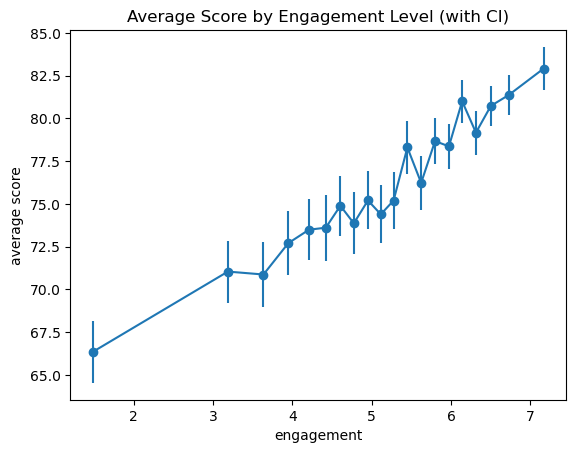

In [ ]:
sample_df = panel_df.reset_index().sample(10000, random_state=42)

sample_df["bin"] = pd.qcut(sample_df["log_engagement_30d"], 20)

bin_stats = sample_df.groupby("bin").agg(
    {"log_engagement_30d": "mean", "score": ["mean", "std", "count"]}
)

bin_stats.columns = ["x", "mean", "std", "n"]

bin_stats["se"] = bin_stats["std"] / (bin_stats["n"] ** 0.5)

plt.errorbar(bin_stats["x"], bin_stats["mean"], yerr=1.96 * bin_stats["se"], fmt="o-")

plt.xlabel("engagement")
plt.ylabel("average score")
plt.title("Average Score by Engagement Level (with CI)")
plt.show()

The figure shows that students with higher engagement levels tend to achieve higher average scores, indicating a clear positive relationship between engagement and performance.

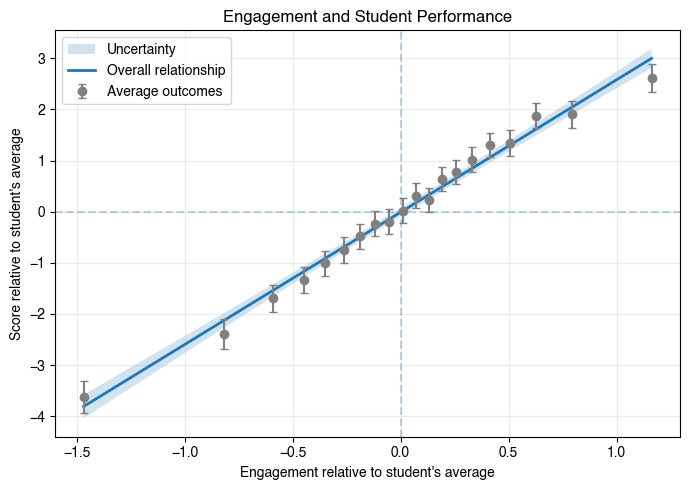

In [ ]:
df = panel_df.reset_index().copy()

# double demean: student FE + assessment FE
df["score_dm"] = df["score"] - df.groupby("id_student")["score"].transform("mean")
df["eng_dm"] = df["log_engagement_30d"] - df.groupby("id_student")[
    "log_engagement_30d"
].transform("mean")

df["score_dm"] = df["score_dm"] - df.groupby("id_assessment")["score_dm"].transform(
    "mean"
)
df["eng_dm"] = df["eng_dm"] - df.groupby("id_assessment")["eng_dm"].transform("mean")

# remove extreme outliers for cleaner visualization
plot_df = df[
    df["eng_dm"].between(df["eng_dm"].quantile(0.01), df["eng_dm"].quantile(0.99))
].copy()

# bin FE-adjusted engagement
plot_df["bin"] = pd.qcut(plot_df["eng_dm"], 20, duplicates="drop")

bin_stats = (
    plot_df.groupby("bin", observed=True)
    .agg(
        x=("eng_dm", "mean"),
        y=("score_dm", "mean"),
        sd=("score_dm", "std"),
        n=("score_dm", "count"),
    )
    .reset_index()
)

bin_stats["se"] = bin_stats["sd"] / np.sqrt(bin_stats["n"])
bin_stats["ci"] = 1.96 * bin_stats["se"]

# linear fit on binned FE-adjusted averages
X = sm.add_constant(bin_stats["x"])
fit = sm.OLS(bin_stats["y"], X).fit()

x_range = np.linspace(bin_stats["x"].min(), bin_stats["x"].max(), 100)
pred = fit.get_prediction(sm.add_constant(x_range)).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(7, 5))

ax.fill_between(
    x_range,
    pred["mean_ci_lower"],
    pred["mean_ci_upper"],
    alpha=0.2,
    label="Uncertainty",
)

ax.plot(x_range, pred["mean"], linewidth=2, label="Overall relationship")

ax.errorbar(
    bin_stats["x"],
    bin_stats["y"],
    yerr=bin_stats["ci"],
    fmt="o",
    capsize=3,
    label="Average outcomes",
    color="gray",
)

ax.axhline(0, linestyle="--", alpha=0.3)
ax.axvline(0, linestyle="--", alpha=0.3)

ax.set_xlabel("Engagement relative to student's average")
ax.set_ylabel("Score relative to student's average")
ax.set_title("Engagement and Student Performance")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Heterogeneity

1. SES (Socio Economic Status)

In [135]:
low_ses_bands = ["0-10%", "10-20%", "20-30%"]

panel_df["low_ses"] = panel_df["imd_band"].isin(low_ses_bands).astype(int)

print(panel_df["low_ses"].value_counts())

low_ses
0    138828
1     34911
Name: count, dtype: int64


In [137]:
panel_df["log_engagement_x_low_ses"] = (
    panel_df["log_engagement_30d"] * panel_df["low_ses"]
)

In [ ]:
model_ses = PanelOLS.from_formula(
    "score ~ log_engagement_30d + log_engagement_x_low_ses + EntityEffects + TimeEffects",
    data=panel_df,
)

result_ses = model_ses.fit(cov_type="clustered", cluster_entity=True)

print(result_ses.summary)

/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/86675271.py:6: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  result_ses = model_ses.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                  score   R-squared:                        0.0108
Estimator:                   PanelOLS   R-squared (Between):              0.2215
No. Observations:              173739   R-squared (Within):               0.0285
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.2178
Time:                        02:26:01   Log-likelihood                 -6.76e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      819.89
Entities:                       23351   P-value                           0.0000
Avg Obs:                       7.4403   Distribution:                F(2,150199)
Min Obs:                       1.0000                                           
Max Obs:                       28.000   F-statistic (robust):             395.58
                            

/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/3070352593.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins = df.groupby("bin").agg({"eng_dm": "mean", "score_dm": ["mean", "std", "count"]})
/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/3070352593.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins = df.groupby("bin").agg({"eng_dm": "mean", "score_dm": ["mean", "std", "count"]})


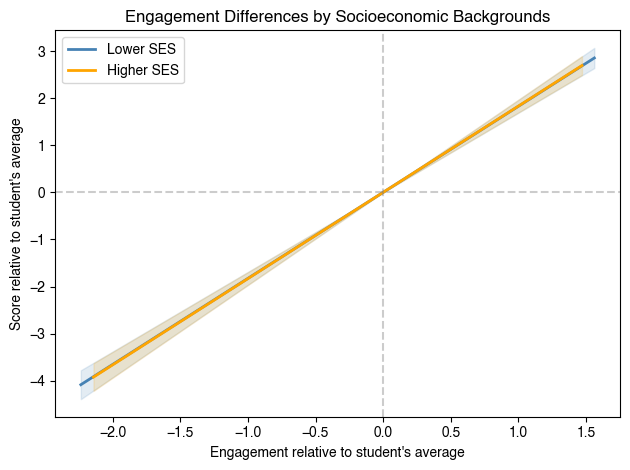

In [ ]:
low_ses = panel_df[panel_df["low_ses"] == 1].reset_index()
high_ses = panel_df[panel_df["low_ses"] == 0].reset_index()

low_ses = demean(low_ses)
high_ses = demean(high_ses)

fig, ax = plt.subplots()

for df, color, label, coef in [
    (low_ses, "steelblue", "Lower SES", 1.8309 - 0.0044),
    (high_ses, "orange", "Higher SES", 1.8309),
]:
    df["bin"] = pd.qcut(df["eng_dm"], 20)
    bins = df.groupby("bin").agg(
        {"eng_dm": "mean", "score_dm": ["mean", "std", "count"]}
    )
    bins.columns = ["x", "mean", "std", "n"]
    bins["se"] = bins["std"] / bins["n"] ** 0.5

    x_range = np.linspace(bins["x"].min(), bins["x"].max(), 100)

    se_line = coef * x_range
    se_band = 0.07 * np.sqrt(x_range**2)
    ax.fill_between(
        x_range,
        se_line - 1.96 * se_band,
        se_line + 1.96 * se_band,
        alpha=0.15,
        color=color,
    )
    ax.plot(x_range, coef * x_range, color=color, linewidth=2, label=label)

ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.axvline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Engagement relative to student's average")
ax.set_ylabel("Score relative to student's average")
ax.set_title("Engagement Differences by Socioeconomic Backgrounds")
ax.legend()
plt.tight_layout()
plt.show()

2. Education 

In [ ]:
panel_df["high_education"] = (
    panel_df["highest_education"]
    .isin(["HE Qualification", "Post Graduate Qualification"])
    .astype(int)
)

In [150]:
panel_df["high_education"].value_counts(normalize=True)

high_education
0    0.830689
1    0.169311
Name: proportion, dtype: float64

In [151]:
panel_df["log_engagement_x_high_education"] = (
    panel_df["log_engagement_30d"] * panel_df["high_education"]
)

In [ ]:
model_edu = PanelOLS.from_formula(
    "score ~ log_engagement_30d + log_engagement_x_high_education + EntityEffects + TimeEffects",
    data=panel_df,
)

result_edu = model_edu.fit(cov_type="clustered", cluster_entity=True)

print(result_edu.summary)

/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/410284745.py:6: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  result_edu = model_edu.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                  score   R-squared:                        0.0109
Estimator:                   PanelOLS   R-squared (Between):              0.2208
No. Observations:              173739   R-squared (Within):               0.0287
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.2168
Time:                        02:42:11   Log-likelihood                 -6.76e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      827.71
Entities:                       23351   P-value                           0.0000
Avg Obs:                       7.4403   Distribution:                F(2,150199)
Min Obs:                       1.0000                                           
Max Obs:                       28.000   F-statistic (robust):             398.84
                            

/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/2372154424.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins = df.groupby("bin").agg({"eng_dm": "mean", "score_dm": ["mean", "std", "count"]})
/var/folders/mh/md5t1d0n6759lkl74jn12rnr0000gn/T/ipykernel_27302/2372154424.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins = df.groupby("bin").agg({"eng_dm": "mean", "score_dm": ["mean", "std", "count"]})


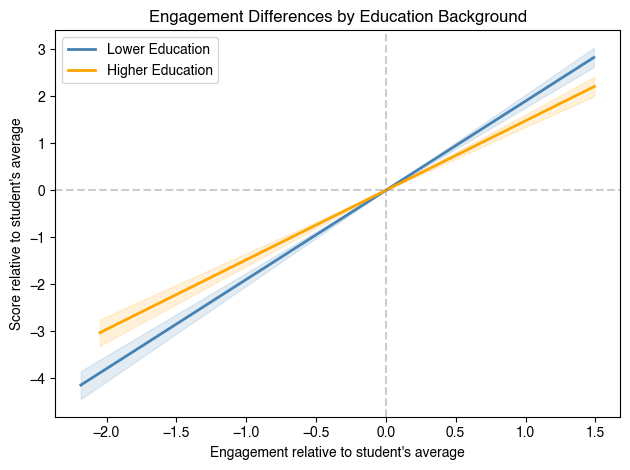

In [ ]:
fig, ax = plt.subplots()

for df, color, label, coef in [
    (low_edu, "steelblue", "Lower Education", 1.8972),
    (high_edu, "orange", "Higher Education", 1.4792),
]:
    # bin averages
    df["bin"] = pd.qcut(df["eng_dm"], 20)
    bins = df.groupby("bin").agg(
        {"eng_dm": "mean", "score_dm": ["mean", "std", "count"]}
    )
    bins.columns = ["x", "mean", "std", "n"]
    bins["se"] = bins["std"] / bins["n"] ** 0.5

    x_range = np.linspace(bins["x"].min(), bins["x"].max(), 100)

    # SE band
    se_line = coef * x_range
    se_band = 0.07 * np.sqrt(x_range**2)
    ax.fill_between(
        x_range,
        se_line - 1.96 * se_band,
        se_line + 1.96 * se_band,
        alpha=0.15,
        color=color,
    )

    # regression line
    ax.plot(x_range, coef * x_range, color=color, linewidth=2, label=label)

ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.axvline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Engagement relative to student's average")
ax.set_ylabel("Score relative to student's average")
ax.set_title("Engagement Differences by Education Background")
ax.legend()
plt.tight_layout()
plt.show()